All the imports to do aswell as the variable to choose if we want to use all the dataset or just a part of it and the random seed for the random generations.

In [25]:
!pip install kaggle
import os
import pandas as pd
import zipfile
import re
import string
from collections import defaultdict
import random
import mmh3
import matplotlib.pyplot as plt
import csv
from typing import Dict, Set, List, Tuple, Optional, Iterable
import time



LARGE_PRIME = 4294967311
RANDOM_SEED = 42
USE_FULL_DATASET = False
DEFAULT_MAX_COMMENTS = 30000


Retrieve the dataset and unzip it

In [26]:
os.environ['KAGGLE_USERNAME'] = "Hursull"
os.environ['KAGGLE_KEY'] = "KGAT_6088b098756a172b6c25a79f9f7dd7de"
!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020
with zipfile.ZipFile("/content/new-york-times-articles-comments-2020.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")




Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
new-york-times-articles-comments-2020.zip: Skipping, found more recently modified local copy (use --force to force download)


The preprocess functions that I use to preprocess a comment, to hash a shingles and the combination of the two to transform a comment to a set of hashed shingles.

In [27]:
### preprocess put the comments in lower case, remove the tagged name @name, remove the punctuation and the stacked up blank space.
### If we are using k-word shingles we remove the comment with less than k words.

def preprocess(comment: str, k: int) -> Optional[str]:
    """Clean and normalize a comment before shingling."""
    if not isinstance(comment, str):
        return None
    comment = comment.lower()
    comment = re.sub(r"@\w+", "", comment)
    comment = re.sub(r"(https?://\S+|www\.\S+)", "", comment)
    comment = comment.translate(str.maketrans("", "", string.punctuation))
    comment = re.sub(r"\s+", " ", comment).strip()
    if len(comment.split()) < k:  #size of the array after putting the comment into an array of word
        return None
    return comment

### We split the comment into an array of word, we build a set to store the shingles.
### Then we loop over the array of words and we join the words to create a k-shingle
### Then we hash that shingle. In the end we return the set containing the shingles for the input comment
def get_word_shingles(comment: str, k: int) -> Set[int]:
    """Generate k-word shingles and hash them."""
    words = comment.split()
    shingles = set()
    for i in range(len(words) - k + 1):
        shingle = " ".join(words[i:i + k])
        shingles.add(mmh3.hash(shingle, signed=False))
    return shingles

###First we clean our comment
###Then use the previous function to get the shingles and hash them.

def process_comment(comment: str, k: int) -> Optional[Set[int]]:
    """Full preprocessing pipeline for a comment."""
    comment_clean = preprocess(comment, k)
    if comment_clean is None:     ### in case the comment is too small
        return None
    shingles = get_word_shingles(comment_clean, k)
    return shingles if shingles else None

These are the functions to generate the hash functions and to compute the signature for a comment.

In [28]:
###To generate the parameters to then have hash functions so then they don't change anymore when we compute the signature.
### This function is actually defining the hash functions of that form f(x) = a*x + b mod(prime).
### So we end up with hash functions
### The function return an array with parameters for allt he n_hash functions

def generate_hash_params(n_hash: int, prime: int) -> List[Tuple[int, int]]:
    """Generate parameters for MinHash functions."""
    return [(random.randint(1, prime - 1), random.randint(0, prime - 1)) for _ in range(n_hash)]


### We create the signature array which has the same number of elements as the number of hash functions (because it's the signature for only 1 comment)
### We iterate over all shingles of the comment for each hash function and we hash the shingles.
### Then we return the signature
def compute_minhash_signature(
    shingles: Set[int], hash_params: List[Tuple[int, int]], prime: int
) -> List[int]:
    """Compute MinHash signature of a set of shingles."""
    signature = [float("inf")] * len(hash_params)
    for shingle_id in sorted(shingles):
        for i, (a, b) in enumerate(hash_params):    #iterate over the hash functions
            h = (a * shingle_id + b) % prime    # hashing of the shingles
            if h < signature[i]:                # We only keep the minimum hash over all the hash functions
                signature[i] = h
    return signature

I created a class to handle the whole LSH part for clarity purposes. In it we store the variables
- r for the number of rows in a band
- b for the number of bans
- buckets which is the list of the buckets we will hash the bands to
- candidate_pairs which is a set containing all the candidate pairs that we found

It contains a function that takes in input a comment with its signature and that do the LSH processing and then add the possible candidate pairs with this comment to the candidate pair set

In [29]:
class LSHIndex:
    """Locality Sensitive Hashing index using banding."""
    def __init__(self, r: int, b: int):
        self.r = r
        self.b = b
        self.buckets: List[Dict[int, List[int]]] = [defaultdict(list) for _ in range(b)]
        self.candidate_pairs: Set[Tuple[int, int]] = set()

    def insert(self, signature: List[int], comment_idx: int) -> None:
        """Insert a signature and update candidate pairs."""
        for band_idx in range(self.b):   #we iterate through all bands
            start = band_idx * self.r
            end = start + self.r
            band_signature = signature[start:end]   # we take only the part of the signature that corresponds to the band
            bucket_id = mmh3.hash64(bytes(str(band_signature), "utf-8"), signed=False)[0]   # we hash the band signature
            bucket = self.buckets[band_idx][bucket_id]    # We retrieve the bucket correspond to this id
            for existing_idx in bucket:     # if we already have element in the bucket then for each of them we add the pair to our candidate pairs set
                pair = tuple(sorted((existing_idx, comment_idx)))
                self.candidate_pairs.add(pair)
            bucket.append(comment_idx)

The functions to compute the Jaccard similarity and to check if candidate pairs are indeed similar or not.

In [30]:
def jaccard_similarity(s1: Set[int], s2: Set[int]) -> float:
    """Compute Jaccard similarity between two sets."""
    union = len(s1 | s2)
    return len(s1 & s2) / union if union else 0.0   # In case the union is empty which means the shingles are empty then we return 0 for no similarity

def compute_true_pairs(
    candidate_pairs: Set[Tuple[int, int]],
    shingle_dict: Dict[int, Set[int]],
    threshold: float
) -> List[Tuple[int, int, float]]:
    """Compute exact Jaccard similarity for candidate pairs."""
    true_pairs = []
    for c1, c2 in candidate_pairs:      # we iterate over all the candidate pairs to check if the Jaccard similarity indeed is above our threshold or not
        jaccard = jaccard_similarity(shingle_dict[c1], shingle_dict[c2])
        if jaccard >= threshold:
            true_pairs.append((c1, c2, jaccard))
    return true_pairs

This is the function to read the csv file as a stream to use less RAM. It read the csv file comment by comment. We can choose a max number of comments to only work on a sample or not. We only look at the "commentBody" attribute which is the text of the comment. This function takes in input the filepath to the csv file. We use yield instead of return so that the function return to its previous state each time so we can advance in the CSV file.

In [31]:
def stream_comments(filepath: str, max_comments: Optional[int] = None) -> Iterable[str]:
    """Stream comments from a CSV file."""
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for idx, row in enumerate(reader):
            if max_comments is not None and idx >= max_comments:
                break
            yield row["commentBody"]

This function is the one operating everything, its the pipeline. In take in argument the parameters we want to use to run everything:
- k the number of words in the shingles
- n_hash the number of hash functions used for the signature
- r the number of rows in a band (no need for b since r*b = n)
- threshold the threshold for the acceptance of candidate pairs

In [32]:
from typing import Tuple, Set, List, Dict

def run_lsh_pipeline(
    filepath: str,
    k: int = 4,
    n_hash: int = 50,
    r: int = 10,
    threshold: float = 0.85,
    use_full_dataset: bool = False,
    max_comments: int = DEFAULT_MAX_COMMENTS,
) -> Tuple[Set[Tuple[int, int]], List[Tuple[int, int, float]], float,
           List[Tuple[str, str]], List[Tuple[str, str]]]:
    """
    Full LSH pipeline that also returns 3 true positive and 3 false positive text pairs to check the results.

    Returns:
        candidate_pairs: set of all candidate index pairs
        true_pairs: list of (idx1, idx2, similarity) for true positives
        threshold: float used for Jaccard similarity threshold
        sample_true_texts: list of 3 (comment1, comment2) true positive texts
        sample_false_texts: list of 3 (comment1, comment2) false positive texts
    """

    prime = LARGE_PRIME
    b = n_hash // r
    hash_params = generate_hash_params(n_hash, prime)   #We setup the hash functions
    lsh = LSHIndex(r, b)                                #We initialise the object for the LSH operations
    shingle_dict: Dict[int, Set[int]] = {}

    all_comments: List[str] = []    #a list to store some comments to then display them

    # Determine how many comments to stream
    stream_limit = None if use_full_dataset else max_comments

    for comment_idx, comment in enumerate(stream_comments(filepath, stream_limit)):
        shingles = process_comment(comment, k)      #we process the comment (preprocess it and shingle it)
        if shingles is None:
            continue
        shingle_dict[comment_idx] = shingles        #We add the shingles (hashed) to our dictionnary
        all_comments.append(comment)                #We store the text for experiment purpose later
        signature = compute_minhash_signature(shingles, hash_params, prime)   #we compute the signature
        lsh.insert(signature, comment_idx)

    true_pairs = compute_true_pairs(lsh.candidate_pairs, shingle_dict, threshold)   #check if the pairs are really similar

    false_positives = list(lsh.candidate_pairs - set((i, j) for i, j, _ in true_pairs))  # the false positive are the pairs in the candidate pair set but not in the final one

    # Get the samples for later analysis
    sample_true_texts = [(all_comments[i], all_comments[j]) for i, j, _ in true_pairs[:3]]
    sample_false_texts = [(all_comments[i], all_comments[j]) for i, j in false_positives[:3]]

    return lsh.candidate_pairs, true_pairs, threshold, sample_true_texts, sample_false_texts

The cell where we run the pipeline on our csv file and display the number of candidate pairs and actual similar pair aswell as the false positive rate.

In [33]:
filepath = "dataset_folder/nyt-comments-part0.csv"
k = 3
n_hash = 50
r = 10

random.seed(RANDOM_SEED)  # We reset the random seed each time before running the pipeline so we are sure to get the same results for the same input
candidate_pairs, true_pairs, threshold, sample_true, sample_false = run_lsh_pipeline(
    filepath,
    k,
    n_hash,
    r,
    use_full_dataset=USE_FULL_DATASET
)

print(f"Candidate pairs : {len(candidate_pairs)}")
print(f"True pairs ≥ {threshold:.4f} : {len(true_pairs)}")

if len(candidate_pairs) > 0:
    false_positive_rate = (len(candidate_pairs) - len(true_pairs)) / len(candidate_pairs)
    print(f"False positive rate : {false_positive_rate:.4f}")
else:
    print("No candidate pairs found.")

Candidate pairs : 191
True pairs ≥ 0.8500 : 177
False positive rate : 0.0733


In this cell we draw a plot to show the distribution of the similar pairs based on their Jaccard similarity. We can see that a lot of them have a Jaccard similarity of 1 because they are actually identic pairs like "I like this article".

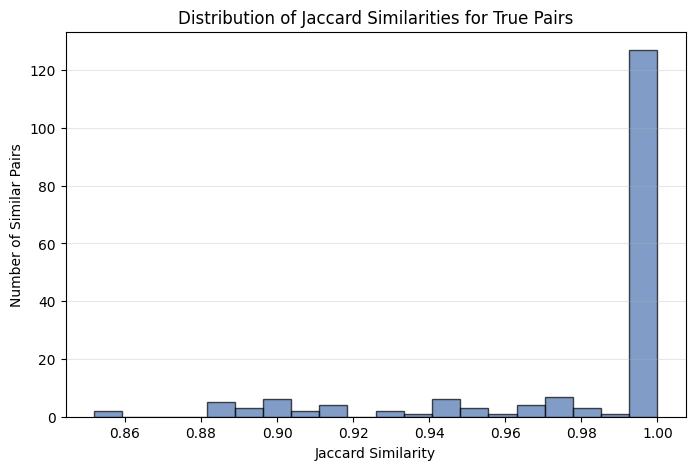

In [34]:
# Extract all Jaccard similarity values
jaccard_values = [sim for _, _, sim in true_pairs]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(jaccard_values, bins=20, color="#4C72B0", edgecolor="black", alpha=0.7)
plt.title("Distribution of Jaccard Similarities for True Pairs")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Similar Pairs")
plt.grid(axis='y', alpha=0.3)
plt.show()

In this cell we show the examples of true positive and false positive so we can check if the results suit our need or not.

In [35]:
print("=== Sample True Positives ===")
for i, (c1, c2) in enumerate(sample_true):
    print(f"{i+1}:\n  FIRST\n{c1}\n  SECOND\n{c2}\n")

print("=== Sample False Positives ===")
for i, (c1, c2) in enumerate(sample_false):
    print(f"{i+1}:\n  FIRST\n{c1}\n  SECOND\n{c2}\n")

=== Sample True Positives ===
1:
  FIRST
@Paul-A You sound remarkably like Trump and his supporters who denigrate our intelligence agencies.
  SECOND
@Maria Ashot
The implication is  that Iran was using Hashd al-Shaabi (see source) to orchestrate attacks on us personnel inside Iraq. Further that they were attempting to avoid responsibility by using an outside organization to do their killing for them.
The further implication is that Hashd al-Shaabi was directed by Suleimani to launch the rocket attacks on which killed and wounded Americans on Friday 12/27, and further directed to launch their attack on the us embassy in Baghdad.
If true, Suleimani was likely in Iraq meeting with the Hashd al-Shaabi leadership to discuss the coordination of more attacks on US interests. 

As such there is no parallel between this situation and the situation in North Korea. I have seen no stories of Korean Generals abroad collaborating with local militias to launch fatal attacks on US personnel.
If N. Ko

This cell purpose is to generate the experiment results

In [36]:
def run_experiments(filepath: str, k_values: List[int], r_values: List[int], n_hash: int = 50, max_comments: int = 30000, threshold: float = 0.85) -> List[Dict]:
    results = []

    for k in k_values:
        for r in r_values:

            start_time = time.time()    #each time we go into the loop we keep track of the time of execution

            # We run the algorithms
            candidate_pairs, true_pairs, _, _, _ = run_lsh_pipeline(
                filepath, k=k, n_hash=n_hash, r=r, use_full_dataset=USE_FULL_DATASET, max_comments=max_comments, threshold = threshold
            )

            # We compute the metrics we want to analyse
            true_positives = len(true_pairs)
            false_positives = len(candidate_pairs) - true_positives
            precision = true_positives / len(candidate_pairs) if candidate_pairs else 0

            execution_time = time.time() - start_time #We get the execution time

            # To keep track of the results
            results.append({
                "k": k,
                "r": r,
                "fixed_threshold": threshold,
                "execution_time": execution_time,
                "candidate_pairs": len(candidate_pairs),
                "true_pairs": true_positives,
                "false_positives": false_positives,
                "precision": precision,
            })

    return results

#the chosen parameters for the experience
k_values = [2, 3, 4]
r_values = [3, 5, 10, 15]
filepath = "dataset_folder/nyt-comments-part0.csv"

experiment_results = run_experiments(filepath, k_values, r_values)

results_df = pd.DataFrame(experiment_results) # we do a dataframe to see the results

results_df = results_df.sort_values(by=["k", "r"])

results_df


,k,r,fixed_threshold,execution_time,candidate_pairs,true_pairs,false_positives,precision
0,2,3,0.85,43.555982,6498,288,6210,0.044321
1,2,5,0.85,49.868759,490,288,202,0.587755
2,2,10,0.85,42.154007,302,278,24,0.920530
3,2,15,0.85,42.501491,281,274,7,0.975089
4,3,3,0.85,42.686068,622,187,435,0.300643
5,3,5,0.85,43.981312,332,187,145,0.563253
6,3,10,0.85,53.089649,191,182,9,0.952880
7,3,15,0.85,41.454884,169,167,2,0.988166
8,4,3,0.85,42.727631,442,142,300,0.321267
9,4,5,0.85,42.252082,235,142,93,0.604255
